# MVP — Machine Learning & Analytics
## Lead Scoring: priorização de leads para o time comercial

**Nome:** Paulo Miguel Mello dos Reis  
**Matrícula:** 4052026000606

**Data:** 05/07/2026

**Dataset:** Lead Scoring Dataset - https://www.kaggle.com/datasets/amritachatterjee09/lead-scoring-dataset

https://github.com/PaulestrinhaM/machinelearning-leadscoring

**Tipo de problema:** Classificação


# 1. Definição do Problema

## 1.1 Descrição

Esse MVP busca criar um modelo capaz de criar um Lead Score para possiveis clientes.

Lead é qualquer pessoa que demonstrou interesse e deixou seus dados, por exemplo preenchendo o formulário de uma campanha.

Lead score é uma nota dada a cada lead que estima o quanto ele tem chance de virar cliente. Quanto maior a nota, maior a probabilidade de conversão. É uma forma de olhar para uma fila de contatos e saber quais valem mais atenção.

Num contexto de marketing digital, o lead score resolve dois problemas práticos.

O primeiro é de diagnóstico. Quando as vendas caem, responde através de dados onde está o problema.
Se é o time comercial, que não está trabalhando bem os contatos, ou é a campanha, que está entregando leads ruins.

Com um score, dá para separar as duas coisas. Se os leads de nota alta não convertem, o gargalo está no comercial.

Se a campanha entrega quase só leads de nota baixa, o problema está na origem.

O segundo é de prioridade. Em época de muito volume, o comercial não dá conta de atender todo mundo. O score define quem atende primeiro, começando pelos leads de maior nota, logo com maior probabilidade de fechar negócio.

Quem usa? times comerciais que captam leads no digital, e a área de marketing,como agências ou profissionais que precisa provar de onde vem o resultado.

Por que importa? sem score, o comercial trabalha a fila por ordem de chegada ou no chute, e ninguém sabe dizer se a verba de campanha está trazendo lead bom. O score faz com que decisões sejam tomadas através de dados ao invés de palpites.

Neste trabalho utilizo uma base pública equivalente a dados de clientes reais. Como o trabalho exige uma base carregável por URL pública, não seria possível usar dados internos, já que isso exporia informações comerciais sensíveis e registros contêm dados pessoais protegidos pela LGPD. Por isso optei por uma base pública equivalente, a Lead Scoring da X Education, que reproduz o mesmo tipo de problema.

## 1.2 Objetivo do MVP
> Construir e avaliar modelos de classificação que estimem a probabilidade de um lead converter, a partir de atributos disponíveis no momento em que o lead entra.

## 1.3 Tipo de problema
**Classificação binária.** A variável-alvo 'Converted' assume 1 (converteu) ou 0 (não converteu). Apesar de a entrega final ser um score contínuo (a probabilidade prevista), o problema de aprendizado é de classificação: aprendemos 'P(Converted=1 | features)'.

Não é série temporal, já que não há ordenação temporal explorável entre os leads. Nem clusterização, já que tem rótulo.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissa:** O modelo só pode usar informação disponível no instante da conversão, ou seja, qualquer atributo preenchido durante/depois do processo comercial (anotações do vendedor, disposição de ligação) é proibido, equivalente a vazamento de dados.

**Hipóteses:**
1. Engajamento no site (tempo total, visitas) prediz conversão melhor que dados cadastrais.
2. Leads vindos de canais que exigem uma ação deliberada (indicação, formulário de proposta) convertem mais do que os de canais passivos (chat, formulário de landing page), porque quem chega por esses canais já vem com intenção mais clara.
3. Leads que recusam ser contatados (marcam Do Not Email / Do Not Call) convertem menos, pois a recusa de contato é um indicador de baixo interesse na oferta.

**Critérios de sucesso:**
- Métrica principal: **ROC-AUC** (mede a qualidade do ranqueamento, que é o que o lead scoring entrega). Secundárias: PR-AUC, F1 e a precisão nas faixas de maior score, que é o que o comercial sente na prática.
- Resultado mínimo: superar com folga o baseline (AUC 0,50) e entregar precisão alta no topo da fila.
- Restrição prática: pipeline reprodutível, sem vazamento, treino em segundos/poucos minutos em CPU.

# 2. Ambiente, Bibliotecas e Reprodutibilidade

In [1]:
# === Setup e reprodutibilidade ===
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, RocCurveDisplay)
from scipy.stats import randint
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 4.5)
print("Ambiente pronto. Seed fixa =", SEED)

Ambiente pronto. Seed fixa = 42


## 2.1 Funções Auxiliares

In [2]:
def metricas_classificacao(y_true, y_pred, proba=None):
    # Métricas de classificação binária. proba = P(classe 1).
    d = {
        "AUC": roc_auc_score(y_true, proba) if proba is not None else np.nan,
        "PR_AUC": average_precision_score(y_true, proba) if proba is not None else np.nan,
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
    }
    return {k: round(v, 4) for k, v in d.items()}

def avalia_pipeline(pipe, Xtr, ytr, Xte, yte, cv, nome):
    # Treina, mede AUC por validação cruzada no treino e métricas no teste.
    t0 = time.time()
    auc_cv = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    pipe.fit(Xtr, ytr)
    dt = time.time() - t0
    proba = pipe.predict_proba(Xte)[:, 1]
    pred = pipe.predict(Xte)
    m = metricas_classificacao(yte, pred, proba)
    m["AUC_CV_treino"] = round(auc_cv, 4)
    m["tempo_s"] = round(dt, 1)
    return m, pipe

# 3. Seleção e Carga dos Dados

## 3.1 Fonte
Base Lead Scoring (X Education), originada do case da UpGrad e disponível publicamente no Kaggle (https://www.kaggle.com/datasets/amritachatterjee09/lead-scoring-dataset). São ~9.240 leads históricos com 37 colunas, cobrindo origem do lead, comportamento no site, dados cadastrais e o desfecho comercial (Converted).

Conforme orientado nas aulas, bases do Kaggle devem ser espelhadas em um repositório público no GitHub e carregadas pela URL raw, garantindo que o notebook rode do início ao fim sem login ou upload manual. Foi o que se fez aqui.

Ética/licença: base real, anonimizada e de uso didático público. Não há dados pessoais identificáveis além dos identificadores internos Prospect ID e Lead Number, removidos por não terem valor preditivo.



##3.2 Carga dos Dados

In [3]:

#https://raw.githubusercontent.com/PaulestrinhaM/machinelearning-leadscoring/main/LeadScoring.csv
DATA_URL = "https://raw.githubusercontent.com/PaulestrinhaM/machinelearning-leadscoring/0dc171c193814eb28ede03def5343582c3ef8c45/Lead%20Scoring.csv"

df = pd.read_csv(DATA_URL)
print("Dataset carregado:", df.shape, "(linhas, colunas)")
df.head(3)

Dataset carregado: (9240, 37) (linhas, colunas)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened


## 3.3 Visão Geral

In [4]:
print("Formato:", df.shape, "(linhas, colunas)")
print("Duplicatas:", df.duplicated().sum())

Formato: (9240, 37) (linhas, colunas)
Duplicatas: 0


In [5]:
print("Tipos de dados:")
display(df.dtypes.value_counts().to_frame("qtde_colunas"))


Tipos de dados:


,qtde_colunas
object,30
float64,4
int64,3


São 9.240 leads e 37 colunas, sem nenhuma linha duplicada. A base é predominantemente categórica: 30 colunas de texto contra 7 numéricas. Das numéricas, só três descrevem comportamento e servem de feature (TotalVisits, Total Time Spent on Website, Page Views Per Visit); as demais são o alvo, um identificador e os Asymmetrique (descartados adiante). Esse predomínio de texto define a estratégia de pré-processamento: o esforço estará em codificar categóricas, não em escalar números.

In [6]:
print("Distribuição do alvo (Converted):")
alvo = df["Converted"].value_counts().to_frame("contagem")
alvo["percentual"] = (df["Converted"].value_counts(normalize=True)*100).round(2)
display(alvo)


Distribuição do alvo (Converted):


,contagem,percentual
Converted,,
0,5679,61.46
1,3561,38.54


O alvo Converted está em 61,5% de não convertidos e 38,5% de convertidos. Portanto temos um desbalanceamento do alvo, ou seja, chutaando sempre "não converte" já acerta 61,5%, por isso a métrica principal será a AUC.
A escolha se dá devido a AUC não olhar acerto de rótulo, e sim se o modelo ordena os leads na direção certa, dando score maior a quem converte do que a quem não converte. Por isso necessita de um ajuste leve de peso de classe nos modelos lineares.

###Problema do 'Select'



Ao inspecionar os valores de "Specialization", se nota que "Select" aparece entre as respostas mais frequentes, o que faz pouco sentido para a coluna, já que não é uma especialização real. A verificação nas demais colunas confirma que o mesmo ocorre em "How did you hear about X Education", "Lead Profile" e "City", somando 13.380 células. Provavelmente é a resposta que o formulário retorna quando o usuário não seleciona nenhuma opção, ou seja, ausência de resposta disfarçada. Por isso, "Select" é tratado como valor nulo, e não como uma categoria própria.


In [7]:
#Número de ausentes menor, antes de contar os 'select' como nulo
print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

Valores ausentes por coluna:


,ausentes
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


In [8]:
# Número de 'Select' no campo Specialization
print(df["Specialization"].value_counts().head(3))

Specialization
Select                       1942
Finance Management            976
Human Resource Management     848
Name: count, dtype: int64


In [9]:
# Busca todas as colunas e conta o "Select" em cada uma
select_por_coluna = (df == "Select").sum()
select_por_coluna = select_por_coluna[select_por_coluna > 0].sort_values(ascending=False)

print("Ocorrências de 'Select' por coluna:")
for col, n in select_por_coluna.items():
    print(f"  {col:36s} {n:5d}  ({n/len(df)*100:.1f}%)")

Ocorrências de 'Select' por coluna:
  How did you hear about X Education    5043  (54.6%)
  Lead Profile                          4146  (44.9%)
  City                                  2249  (24.3%)
  Specialization                        1942  (21.0%)


In [10]:
df = df.replace("Select", np.nan)
df["Lead Source"] = df["Lead Source"].str.lower()   # 'Google' e 'google' viram a mesma fonte

In [11]:
#Número de ausentes correto, contabilizando 'Select" como nulo
print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

Valores ausentes por coluna:


,ausentes
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


In [12]:
print("Duplicatas:", df.duplicated().sum())

Duplicatas: 0


Definição do Target

O alvo é 'Converted', se o lead converteu em cliente ou não. É binário, o que define o problema como classificação. A distribuição é 61,5% de para 38,5%. Não há valor contínuo a prever o que o modelo estima é a probabilidade de a classe ser 1, e essa probabilidade vira o lead score. É o único alvo da base, não há ambiguidade sobre o que prever.

In [13]:
print("Variável-alvo: Converted")
print(df["Converted"].value_counts().to_frame("contagem"))
print(f"\nTaxa de conversão: {df['Converted'].mean()*100:.1f}%")

Variável-alvo: Converted
           contagem
Converted          
0              5679
1              3561

Taxa de conversão: 38.5%


Identificadores e valores que não devem entrar no modelo

'Prospect ID' e 'Lead Number' têm um valor único por linha. Não têm poder preditivo e não devem entrar no treinamento.

'Tags', 'Lead Quality' e 'Last Notable Activity' são preenchidas manualmebte durante ou após o contato comercial. Não existem no momento do scoring e serão descartadas


In [14]:
# Identificadores: uma linha por lead, sem valor preditivo
print("Cardinalidade dos identificadores (nº de valores únicos):")
print(f"  Prospect ID: {df['Prospect ID'].nunique()} únicos em {len(df)} linhas")
print(f"  Lead Number: {df['Lead Number'].nunique()} únicos em {len(df)} linhas")

# Confirma que não há coluna de data/hora
print("\nColunas do tipo data:", list(df.select_dtypes(include='datetime').columns) or "nenhuma")

Cardinalidade dos identificadores (nº de valores únicos):
  Prospect ID: 9240 únicos em 9240 linhas
  Lead Number: 9240 únicos em 9240 linhas

Colunas do tipo data: nenhuma


# 4. Análise Exploratória


## 4.0.1 Conversão por origem do lead

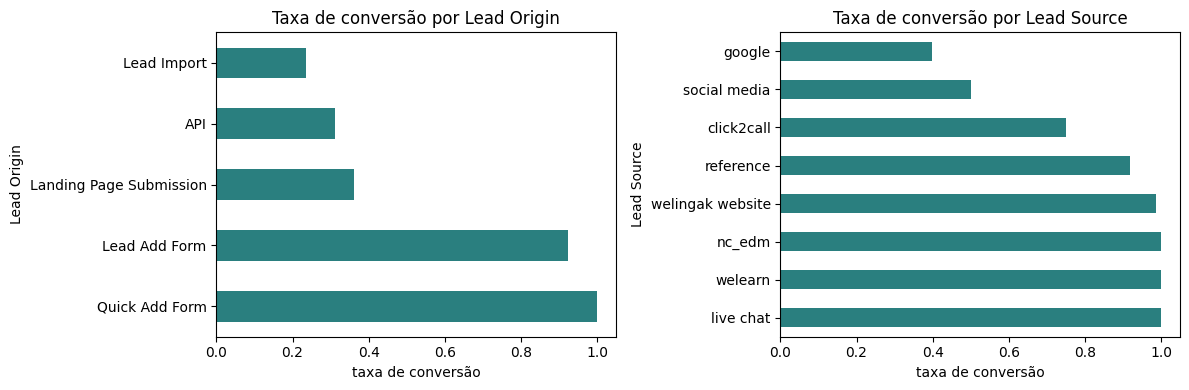

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, ["Lead Origin", "Lead Source"]):
    g = df.groupby(col)["Converted"].mean().sort_values(ascending=False).head(8)
    g.plot(kind="barh", ax=ax, color="#2a7f7f")
    ax.set_title("Taxa de conversão por "+col); ax.set_xlabel("taxa de conversão")
plt.tight_layout(); plt.show()

Origens como Lead Add Form e fontes como "Welingak Website" e "Reference" convertem muito acima da média, enquanto "Olark Chat" e "Landing Page Submission" ficam abaixo. A origem carrega sinal real e está disponível na entrada do lead, portanto entra no modelo

## 4.0.2 O problema central: vazamento de dados

In [16]:
print("=== Taxa de conversão por Tags (anotação do vendedor) ===")
print(df.groupby("Tags")["Converted"].agg(["count","mean"]).sort_values("count",ascending=False).head(8).round(3).to_string())
print("\n=== Taxa de conversão por Lead Quality (palpite do vendedor) ===")
print(df.groupby("Lead Quality")["Converted"].agg(["count","mean"]).round(3).to_string())

=== Taxa de conversão por Tags (anotação do vendedor) ===
                                     count   mean
Tags                                             
Will revert after reading the email   2072  0.969
Ringing                               1203  0.028
Interested in other courses            513  0.025
Already a student                      465  0.006
Closed by Horizzon                     358  0.994
switched off                           240  0.017
Busy                                   186  0.565
Lost to EINS                           175  0.977

=== Taxa de conversão por Lead Quality (palpite do vendedor) ===
                   count   mean
Lead Quality                   
High in Relevance    637  0.947
Low in Relevance     583  0.818
Might be            1560  0.756
Not Sure            1092  0.244
Worst                601  0.020


Tags como 'Closed by Horizzon' tem 99% conversão ou 'Will revert after reading the email' tem 97% e a coluna 'Lead Quality' "High in Relevance" tem 95% e não são causas da conversão, são consequências do processo comercial

O vendedor preenche isso depois de trabalhar o lead. No instante em que precisamos pontuar um lead novo, esses campos não existem.

Usar é vazamento, o modelo estaria prevendo o passado.

Por isso 'Tags', 'Lead Quality' e a atividade pós-contato são descartadas.

## 4.0.3 Colunas de variância nula

Várias colunas binárias 'Magazine', 'Newspaper', 'Do Not Call', entre outras têm praticamente todos os registros num único valor. Não informa nada e só aumenta a dimensionalidade. A verificação abaixo identifica essas colunas para descarte.

In [17]:
# Colunas onde um único valor concentra 99,5% ou mais dos registros
quase_constantes = []
for c in df.columns:
    top = df[c].value_counts(normalize=True, dropna=False).iloc[0]
    if top >= 0.995:
        quase_constantes.append((c, round(top, 3)))

print("Colunas (quase) constantes (>= 99,5% num único valor):")
for c, s in quase_constantes:
    print(f"  {c:45s} {s}")

Colunas (quase) constantes (>= 99,5% num único valor):
  Do Not Call                                   1.0
  Search                                        0.998
  Magazine                                      1.0
  Newspaper Article                             1.0
  X Education Forums                            1.0
  Newspaper                                     1.0
  Digital Advertisement                         1.0
  Through Recommendations                       0.999
  Receive More Updates About Our Courses        1.0
  Update me on Supply Chain Content             1.0
  Get updates on DM Content                     1.0
  I agree to pay the amount through cheque      1.0


## 4.1 Síntese da análise exploratória


O target está balanceado?
Não. Desbalanceamento moderado, 38,5% de conversão contra 61,5%. Isso basta para descartar a acurácia como métrica principal e adotar a AUC, sem exigir reamostragem.

Existem valores ausentes relevantes? Sim, o nível "Select" mascarava ausência em quatro colunas, 13.380 células. Tratado como nulo, o retrato real mostra colunas de 45% a 78% de ausência (How did you hear, Lead Profile, Asymmetrique), que serão descartadas, e faltantes tratáveis de 1% a 40% (City, Specialization, numéricos), que serão imputados.

Há variáveis com escala muito diferente? Sim. Total Time Spent on Website está na casa dos milhares, enquanto TotalVisits e Page Views Per Visit ficam abaixo de algumas dezenas. O que exige padronização das numéricas no pré-processamento.

Há categorias raras? Sim. Fontes e atividades com pouquíssimas ocorrências, além de grafias duplicadas (Google/google). Isso justifica agrupar categorias raras no encoding para não explodir a dimensionalidade nem criar colunas quase vazias.

Há padrões que sugerem quais modelos podem funcionar melhor? Sim. As relações entre features e target não são lineares, e a base mistura numéricas com muitas categóricas. Esse perfil favorece modelos baseados em árvore e boosting, o que orienta a escolha dos candidatos.

Algum resultado da EDA mudou a estratégia? Sim, o principal do trabalho. A exploração revelou que "Tags" e "Lead Quality", apesar de altíssimo poder preditivo, são anotações pós-contato, o que configuraria como vazamento. Isso mudou a estratégia de features, que passou a excluir por princípio tudo indisponível no momento do scoring. A EDA também definiu imputar por mediana (por causa dos outliers) e não remover esses outliers, por serem engajamento real.

## 4.1.1 Balanceamento do target


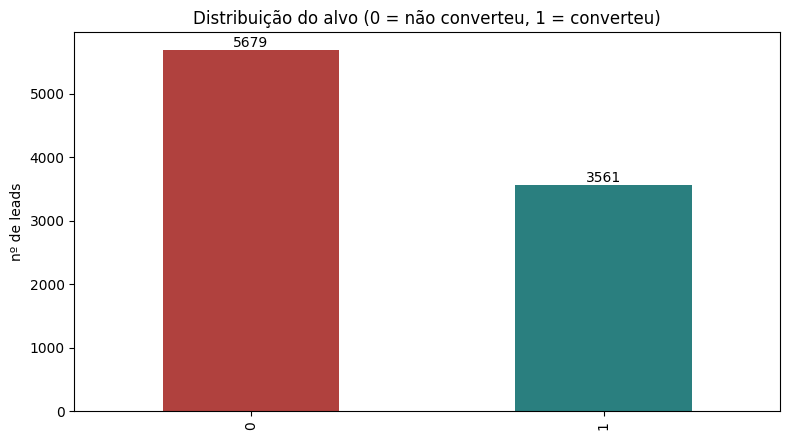

Taxa de conversão: 38.5%


In [18]:
ax = df["Converted"].value_counts().sort_index().plot(kind="bar", color=["#b0413e","#2a7f7f"])
ax.set_title("Distribuição do alvo (0 = não converteu, 1 = converteu)")
ax.set_xlabel(""); ax.set_ylabel("nº de leads")
for i,v in enumerate(df["Converted"].value_counts().sort_index()):
    ax.text(i, v+50, str(v), ha="center")
plt.tight_layout(); plt.show()
print("Taxa de conversão: %.1f%%" % (df["Converted"].mean()*100))

38,5% de conversão. Há desbalanceamento moderado. A métrica principal é AUC e não acurácia, e basta peso de classe nos modelos lineares, sem reamostragem.

## 4.1.2 Valores Ausentes


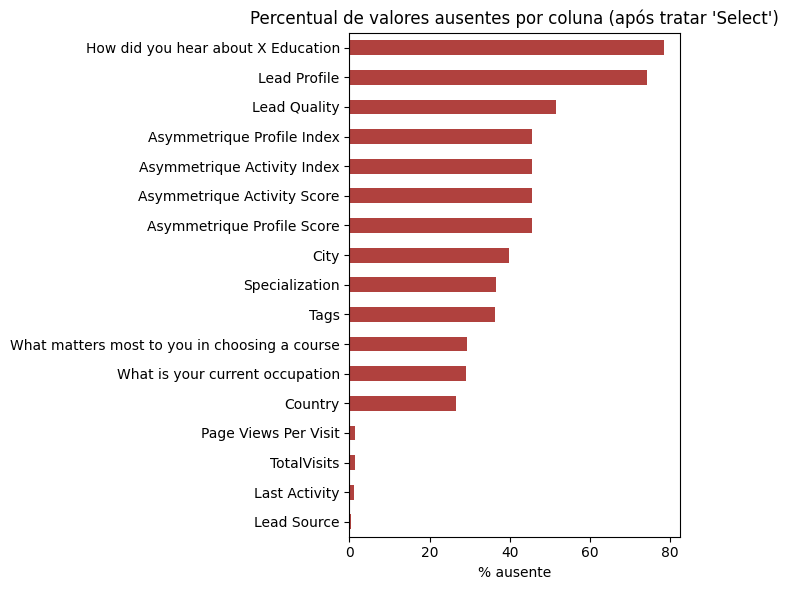

In [19]:
faltantes = (df.isna().mean()*100).round(1).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
ax = faltantes.plot(kind="barh", figsize=(7,6), color="#b0413e")
ax.set_title("Percentual de valores ausentes por coluna (após tratar 'Select')")
ax.set_xlabel("% ausente"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

"How did you hear", "Lead Profile", "Asymmetrique" "Lead Quality" são irrecuperáveis e serão descartadoa.

## 4.1.3 Escalas Diferentes


In [20]:
num = ["TotalVisits", "Total Time Spent on Website", "Page Views Per Visit"]
display(df[num].describe().round(2))

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,9103.00,9240.00,9103.00
mean,3.45,487.70,2.36
std,4.85,548.02,2.16
min,0.00,0.00,0.00
25%,1.00,12.00,1.00
50%,3.00,248.00,2.00
75%,5.00,936.00,3.00
max,251.00,2272.00,55.00


Os números de max e média de "Total Time Spent on Website" chega a milhares, enquanto "Page Views Per Visit" e "TotalVisits" ficam em dezenas. Escalas em ordens de grandeza diferentes.

## 4.1.4 Categorias Raras

In [21]:
print("Frequência em Lead Source (note a cauda de categorias raras):")
print(df["Lead Source"].value_counts().to_string())

Frequência em Lead Source (note a cauda de categorias raras):
Lead Source
google               2873
direct traffic       2543
olark chat           1755
organic search       1154
reference             534
welingak website      142
referral sites        125
facebook               55
bing                    6
click2call              4
live chat               2
social media            2
press_release           2
pay per click ads       1
blog                    1
welearn                 1
welearnblog_home        1
youtubechannel          1
testone                 1
nc_edm                  1


As primeiras fontes concentram quase tudo e há algumas categorias com pouquíssimas ocorrências

##4.1.5 Modelo

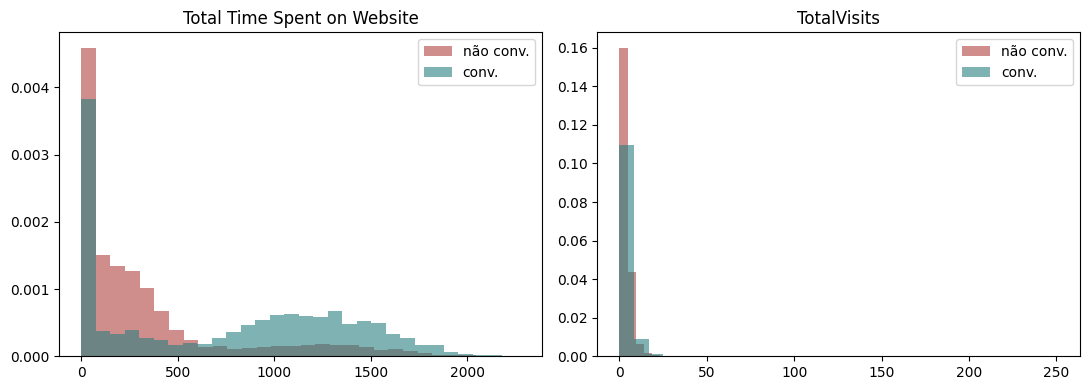

           mediana
Converted         
0            179.0
1            832.0


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax, col in zip(axes, ["Total Time Spent on Website", "TotalVisits"]):
    for k, c, lbl in [(0, "#b0413e", "não conv."), (1, "#2a7f7f", "conv.")]:
        ax.hist(df.loc[df.Converted == k, col].dropna(), bins=30, alpha=0.6,
                color=c, label=lbl, density=True)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

print(df.groupby("Converted")["Total Time Spent on Website"].median().to_frame("mediana"))

O tempo no site separa as classes, quem converte se concentra numa faixa de tempo bem maior, e a mediana dos convertidos fica muito acima. TotalVisits quase não separa as duas distribuições se sobrepõem.

A base é dominada por categóricas, o que favorece modelos de árvore e boosting, que capturam esse tipo de fronteira melhor que um modelo linear.

In [23]:
print("Taxa de conversão por Tags (anotação pós-contato do vendedor):")
display(df.groupby("Tags")["Converted"].agg(["count", "mean"])
          .sort_values("count", ascending=False).head(8).round(3))

print("\nTaxa de conversão por Lead Quality (palpite do vendedor):")
display(df.groupby("Lead Quality")["Converted"].agg(["count", "mean"]).round(3))

Taxa de conversão por Tags (anotação pós-contato do vendedor):


,count,mean
Tags,,
Will revert after reading the email,2072,0.969
Ringing,1203,0.028
Interested in other courses,513,0.025
Already a student,465,0.006
Closed by Horizzon,358,0.994
switched off,240,0.017
Busy,186,0.565
Lost to EINS,175,0.977



Taxa de conversão por Lead Quality (palpite do vendedor):


,count,mean
Lead Quality,,
High in Relevance,637,0.947
Low in Relevance,583,0.818
Might be,1560,0.756
Not Sure,1092,0.244
Worst,601,0.020


 Tags como "Closed by Horizzon" converte 99%, "Will revert after reading the email" 97%, e Lead Quality "High in Relevance" 95%.

 Essas colunas não descrevem o lead, descrevem o que o vendedor já fez com ele. São preenchidas durante ou depois do contato, e não existem no instante em que um lead novo precisa ser pontuado. A exploração desses dados pode ser interpretada com um vazamento, já que esse dado não está disponível no momento do scoring. portanto faz sentido descartar essas colunas para evitar vazamento
.

# 5. Preparação dos dados e divisão treino/teste



## 5.0.1 Seleção de features

O alvo é Converted. As 37 colunas da base se dividem em quatro grupos, e apenas o primeiro se torna feature.

Grupo 1, features usadas (12 colunas). Três numéricas de comportamento no site ('TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit') e nove categóricas disponíveis no momento em que o lead chega: origem e fonte do lead, ocupação, especialização, cidade, país, e os indicadores de contato ('Do Not Email', 'Last Activity', 'A free copy of Mastering The Interview'). O critério para entrar neste grupo é um só: a informação precisa existir no instante do scoring.

Grupo 2, descartadas por vazamento (3 colunas).'Tags', 'Lead Quality' e 'Last Notable Activity' são anotações preenchidas pelo time comercial durante ou depois do contato. Como demonstrado na seção 4.4, têm poder preditivo altíssimo justamente porque carregam o desfecho, mas não existem quando um lead novo precisa ser pontuado. São removidas por nã fazerem sentido, não por desempenho.

Grupo 3, descartadas por falta de sinal. Os identificadores 'Prospect ID' e 'Lead Number' (um valor único por lead, sem poder preditivo), colunas com mais de 70% de nulos ('How did you hear about X Education', 'Lead Profile'), os quatro scores 'Asymmetrique' (derivados pela empresa e com 45% de ausência), e 'What matters most to you in choosing a course', quase constante.

Grupo 4, descartadas por variância quase nula. As colunas binárias identificadas na seção 4.5, com 99,5% ou mais dos registros num único valor.

A separação em grupos torna auditável cada coluna que entra e cada uma que sai, com o motivo ao lado

In [24]:
# === Configuração do problema ===

TARGET = "Converted"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ["Prospect ID", "Lead Number"]
DATE_COLUMN = None                 # a base não possui eixo temporal

# Colunas removidas por vazamento, irrelevância ou indisponibilidade no uso real.
# Vazamento (anotações pós-contato, ver 4.4):
LEAKAGE = ["Tags", "Lead Quality", "Last Notable Activity"]
# Sem sinal: >70% nulos, scores derivados com 45% nulo, quase constante:
SEM_SINAL = ["How did you hear about X Education", "Lead Profile",
             "What matters most to you in choosing a course",
             "Asymmetrique Activity Index", "Asymmetrique Profile Index",
             "Asymmetrique Activity Score", "Asymmetrique Profile Score"]
# Variância quase nula (ver 4.5):
VARIANCIA_NULA = [c for c, _ in quase_constantes]

DROP_COLUMNS = LEAKAGE + SEM_SINAL + VARIANCIA_NULA

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: Converted
Número de features: 12
Features: ['Lead Origin', 'Lead Source', 'Do Not Email', 'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity', 'Country', 'Specialization', 'What is your current occupation', 'City', 'A free copy of Mastering The Interview']


## 5.0.2 Divisão treino/teste

Os dados caem na divisão 80/20 estratificada pelo alvo.

Estratificação, mantém a proporção de conversão (38,5%) igual nas duas partições. Sem ela, o acaso da divisão poderia deixar treino e teste com taxas diferentes, distorcendo o aprendizado e a avaliação.

Embaralhamento como não é um problema com aspecto temporal, embaralhar não cria vazamento de futuro no passado, então a divisão aleatória estratificada é adequada.

Isolamento do teste, o conjunto de teste só é usado na avaliação final da seção 10. Toda decisão de pré-processamento e de hiperparâmetro usa apenas o treino, via validação cruzada (seção 9), para não contaminar a estimativa de desempenho.

In [25]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")

Treino: (7392, 12) | Teste: (1848, 12)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Conversão treino: %.3f | teste: %.3f" % (y_train.mean(), y_test.mean()))

Treino: (7392, 12) | Teste: (1848, 12)
Conversão treino: 0.385 | teste: 0.385


## 5.1 Justificativa da divisão



**Por que holdout e não outra estratégia?** O problema é supervisionado e não temporal, então o holdout é adequado.
A divisão temporal não se aplica, porque a base não tem eixo de tempo. A validação cruzada é usada, mas dentro do treino, para escolher hiperparâmetros, o holdout garante um conjunto de teste que nunca participou de nenhuma decisão, dando uma estimativa honesta de desempenho no fim.

**A proporção 80/20 faz sentido para o tamanho da base?** Sim. Com 9.240 leads, 20% reservam cerca de 1.848 registros para teste, amostra grande o bastante para uma estimativa estável de AUC, e mantêm 80% para treino, suficiente para os modelos aprenderem.

**Foi necessário estratificar?** Sim. O alvo é desbalanceado (38,5% de conversão), e sem estratificação o sorteio poderia deixar treino e teste com proporções diferentes de convertidos, enviesando o aprendizado e a avaliação. A estratificação força as duas partições a manterem os mesmos 38,5%, garantindo comparação justa.

**Como a divisão evita vazamento?** De duas formas. Primeiro, o teste é separado antes de qualquer transformação e só é tocado na avaliação final, nenhuma decisão de modelagem o enxerga. Segundo, todo o pré-processamento (imputação, padronização, codificação) vive dentro de um pipeline ajustado apenas no treino de cada fold, então nenhuma estatística do teste vaza para o treino. É a diferença entre ajustar a mediana de imputação na base inteira e ajustá-la só no treino.

# 6. Pré-processamento e pipeline

Com as features definidas e os dados divididos, esta etapa monta a sequência de transformações que prepara os dados para os modelos. Tudo é encapsulado em um pipeline reprodutível, que garante duas coisas, as transformações rodam sempre na mesma ordem, e são ajustadas apenas no treino, nunca no teste.

Nesta base, o pré-processamento cobre três operações: imputação dos valores ausentes que sobraram após a limpeza, padronização das numéricas e codificação das categóricas.

In [27]:
# Identificação de colunas numéricas e categóricas a partir das features já selecionadas (seção 5)
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconhecido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
Colunas categóricas: ['Lead Origin', 'Lead Source', 'Do Not Email', 'Last Activity', 'Country', 'Specialization', 'What is your current occupation', 'City', 'A free copy of Mastering The Interview']


**Por que mediana na imputação numérica?** As numéricas ('TotalVisits', 'Page Views Per Visit') têm outliers, leads com muitas visitas, portanto a mediana resiste a esses valores extremos, enquanto a média seria puxada por eles. Por isso mediana, não média.

**Por que padronizar?** A regressão logística é sensível à escala das variáveis, e as numéricas têm escalas muito diferentes (tempo no site na casa dos milhares, visitas em dezenas). A padronização coloca todas na mesma escala, o que faz o modelo linear convergir bem e não dar peso indevido à variável de maior magnitude.

**Por que "Desconhecido" na imputação categórica?** Os nulos viram uma categoria própria em vez de serem preenchidos com a categoria mais comum. Nesta base, "não preencheu" costuma ser informativo: um lead que deixou a especialização em branco difere de um que escolheu uma. Preservar isso como categoria mantém o sinal.

**Por que agrupar categorias raras?** O 'min_frequency=20' junta categorias com menos de 20 ocorrências num grupo único. Sem isso, o One-Hot criaria dezenas de colunas quase vazias (uma por categoria rara), inflando a dimensionalidade com ruído, conforme apontado na análise exploratória.

**Criei novas variáveis?** Não. Nenhuma feature nova foi construída as features existentes já respondem à premissa de estarem disponíveis no momento do scoring.

**Como o pipeline evita vazamento?** Todo o pré-processamento vive dentro do 'ColumnTransformer'. Na validação cruzada e no treino, imputador, scaler e encoder são ajustados apenas com os dados de treino de cada fold, e depois aplicados ao teste. Nenhuma estatística do teste (mediana, categorias, frequências) influencia o ajuste.

# 7. Baseline e modelos candidatos



**Baseline: "DummyClassifier(strategy="prior")".** Ele prevê conforme a proporção das classes, sem olhar nenhuma feature. É o piso: acerta os 61,5% da classe majoritária, mas tem AUC 0,50, porque não ordena nada. Se um modelo não superar isso com folga, não está aprendendo.

**Candidatos.** Quatro modelos, escolhidos por dois motivos. A regressão logística devolve uma probabilidade, que é exatamente o formato do lead score que se quer entregar e é interpretável, cada feature tem um peso com sinal, o que atende ao uso de diagnóstico de separar problema de campanha de problema de comercial.

 Random forest e os dois de gradient boosting (GradientBoosting e HistGradientBoosting), entram porque a análise exploratória mostrou relações não lineares e a base é dominada por categóricas, terreno onde árvore e boosting costumam ganhar do modelo linear. Os quatro rodam sob o mesmo pré-processamento e a mesma validação.

In [28]:
# === Baseline e modelos candidatos ===

def faz_pipe(modelo):
    return Pipeline(steps=[("preprocess", preprocess), ("model", modelo)])

baseline = faz_pipe(DummyClassifier(strategy="prior", random_state=SEED))

candidates = {
    "Reg. Logística":    faz_pipe(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    "Random Forest":     faz_pipe(RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=SEED)),
    "Gradient Boosting": faz_pipe(GradientBoostingClassifier(random_state=SEED)),
    "HistGradientBoost": faz_pipe(HistGradientBoostingClassifier(random_state=SEED)),
}

print("Baseline:", baseline.named_steps["model"].__class__.__name__)
print("Candidatos:", list(candidates.keys()))

Baseline: DummyClassifier
Candidatos: ['Reg. Logística', 'Random Forest', 'Gradient Boosting', 'HistGradientBoost']


## 7.1 Justificativa dos modelos e ajustes feitos


**Por que estes quatro.** A regressão logística entra por duas razões, devolve uma probabilidade, que é o formato do lead score, e é interpretável, com um peso por feature. Random forest e os dois de boosting entram porque a análise exploratória mostrou relações não lineares e a base é dominada por categóricas, terreno onde árvore e boosting costumam superar o modelo linear. Manter os quatro, e não só o melhor, deixa a comparação rica: mostra que a logística chega perto do topo e que boosting ganha do random forest nesta base, o que não era garantido de antemão.

**Ajuste 1, o baseline.** A primeira versão usou 'strategy="most_frequent"', que crava toda previsão numa classe só. O problema apareceu ao medir AUC: com previsão cravada, o 'predict_proba' não varia e a métrica perde o sentido. Foi substituido por 'strategy="prior"', que devolve a proporção das classes e produz um AUC de 0,50 coerente, o piso real de um modelo que não ordena nada.

**Ajuste 2, o desbalanceamento.** Nas primeiras rodadas, a regressão logística e o random forest saíram com recall baixo na classe convertida: acertavam os não convertidos e perdiam conversões. Foi adicionado 'class_weight="balanced"', que dá mais peso à classe minoritária no treino. O recall dos convertidos subiu sem derrubar o AUC. Os modelos de boosting não receberam o parâmetro porque lidam com o desbalanceamento moderado por conta própria.

**Ajuste 3, a quebra do HistGradientBoosting.** Na primeira execução completa, o HistGB quebrou com erro de matriz esparsa. O modelo não rodava. A correção foi 'sparse_output=False' no encoder, que passou a entregar matriz densa.

**Ajuste 4, a convergência da logística.** O default de 'max_iter' gerava aviso de não convergência: o otimizador parava antes de estabilizar. Subir para 'max_iter=1000' resolveu.

# 8. Treinamento e avaliação inicial

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados = {}
pipes_treinados = {}

# Baseline primeiro (a régua de referência)
m, fit_pipe = avalia_pipeline(baseline, X_train, y_train, X_test, y_test, cv, "Baseline (Dummy)")
resultados["Baseline (Dummy)"] = m
pipes_treinados["Baseline (Dummy)"] = fit_pipe
print(f"{'Baseline (Dummy)':18s} AUC_cv={m['AUC_CV_treino']:.3f} | teste AUC={m['AUC']:.3f} PR-AUC={m['PR_AUC']:.3f} F1={m['F1']:.3f} Acc={m['Accuracy']:.3f} ({m['tempo_s']}s)")

# Modelos candidatos
for nome, pipe in candidates.items():
    m, fit_pipe = avalia_pipeline(pipe, X_train, y_train, X_test, y_test, cv, nome)
    resultados[nome] = m
    pipes_treinados[nome] = fit_pipe
    print(f"{nome:18s} AUC_cv={m['AUC_CV_treino']:.3f} | teste AUC={m['AUC']:.3f} PR-AUC={m['PR_AUC']:.3f} F1={m['F1']:.3f} Acc={m['Accuracy']:.3f} ({m['tempo_s']}s)")

tab = pd.DataFrame(resultados).T[["AUC_CV_treino","AUC","PR_AUC","F1","Precision","Recall","Accuracy","tempo_s"]]
tab

Baseline (Dummy)   AUC_cv=0.500 | teste AUC=0.500 PR-AUC=0.385 F1=0.000 Acc=0.615 (6.9s)
Reg. Logística     AUC_cv=0.897 | teste AUC=0.875 PR-AUC=0.806 F1=0.755 Acc=0.802 (3.7s)
Random Forest      AUC_cv=0.896 | teste AUC=0.872 PR-AUC=0.806 F1=0.743 Acc=0.804 (19.3s)
Gradient Boosting  AUC_cv=0.906 | teste AUC=0.889 PR-AUC=0.831 F1=0.770 Acc=0.823 (8.2s)
HistGradientBoost  AUC_cv=0.906 | teste AUC=0.888 PR-AUC=0.837 F1=0.769 Acc=0.821 (4.7s)


,AUC_CV_treino,AUC,PR_AUC,F1,Precision,Recall,Accuracy,tempo_s
Baseline (Dummy),0.5000,0.5000,0.3853,0.0000,0.0000,0.0000,0.6147,6.9
Reg. Logística,0.8975,0.8747,0.8062,0.7552,0.7227,0.7907,0.8025,3.7
Random Forest,0.8961,0.8723,0.8059,0.7433,0.7507,0.7360,0.8041,19.3
Gradient Boosting,0.9062,0.8894,0.8310,0.7696,0.7723,0.7669,0.8231,8.2
HistGradientBoost,0.9059,0.8880,0.8367,0.7692,0.7660,0.7725,0.8214,4.7


## 8.1 Análise dos resultados iniciais



**Os modelos superaram o baseline?** Sim, com folga larga. O baseline tem AUC 0,50 (não ordena nada), e os quatro candidatos ficam entre 0,87 e 0,89. Demonstra que o problema pode ser solucionado e os modelos aprenderam de fato.

**Qual modelo lidera?** Os dois de boosting empatam no topo: Gradient Boosting com AUC de teste 0,889 e HistGradientBoosting com 0,888, praticamente idênticos. A regressão logística (0,875) e o random forest (0,872) vêm logo atrás.


---


**A métrica escolhida é suficiente?**

**AUC:** Lead scoring é um problema de ordenação, logo rankear os leads do mais quente ao mais frio. A AUC mede a qualidade dessa ordem e independe de um corte de decisão, por isso é a métrica principal.

**Precisão por faixa de topo:** O comercial trabalha os X% de maior score, não os leads acima de 0,5. A precisão nos decis do topo mede o que a operação sente na prática, ligando o modelo ao resultado comercial.

**PR-AUC:** Mais sensível ao desempenho na classe convertida que a AUC, útil por essa ser a classe de interesse e a minoritária.

**F1, precisão e recall:** Retratam o equilíbrio entre capturar convertidos e não errar ao apontá-los, mas assumem corte fixo em 0,5, que não é como o scoring é usado. Servem para comparar modelos.

**Acurácia:** Reportada, mas não guia a decisão. Como a base é desequilibrada com 38,5% de conversão, prever sempre como não conversão já daria 61,5%, um número alto e vazio.

**Matriz de confusão** Mostra a distribuição de acertos e erros entre as classes num corte fixo, útil para ver onde o modelo erra.


---



**Há underfitting ou overfitting?** Nenhum dos dois. Underfitting está descartado porque todos superam o baseline com folga. Overfitting também: o AUC de validação cruzada no treino (em torno de 0,906 nos melhores) fica próximo do AUC de teste.

**O tempo de treino é aceitável?** Sim. O mais lento (random forest) treina em segundos.

**O resultado faz sentido com a análise exploratória?** Faz. A exploração mostrou relações não lineares e predomínio de categóricas, terreno de boosting, e é o boosting que lidera. Também indicou que a logística não ficaria muito atrás, porque parte do sinal (tempo no site, origem) é forte e direto, o que se confirma no seu AUC próximo do topo.

## 9. Validação e otimização de hiperparâmetros


**Modelo otimizado:** HistGradientBoosting, o melhor dos candidatos na avaliação inicial.

**Hiperparâmetros testados:** 'learning_rate', 'max_leaf_nodes', 'max_depth' e 'min_samples_leaf', 'l2_regularization'.

**Estratégia de validação:** validação cruzada estratificada de 5 folds, aplicada só no treino. O conjunto de teste não participou da busca.

**Métrica que guiou a escolha:** AUC, coerente com a métrica principal do trabalho. Cada combinação foi julgada pela AUC média nos 5 folds.

**Melhor configuração encontrada:** 'learning_rate=0.1', 'max_depth=5', 'max_leaf_nodes=56', 'min_samples_leaf=34', 'l2_regularization=0.0', com AUC de validação de 0,907.

## 9.1 Discussão da otimização


**A otimização melhorou o resultado?** Pouco. O AUC de teste passou de 0,888 (HistGB default) para 0,890 (otimizado), praticamente nada de ganho.

**Os hiperparâmetros escolhidos fazem sentido?** Sim. 'learning_rate', 'max_leaf_nodes' e 'max_depth' controlam a capacidade do modelo, e 'min_samples_leaf' e 'l2_regularization' regularizam. São exatamente os botões que equilibram ajuste e generalização num modelo de boosting, por isso foram os escolhidos para a busca.

**A busca foi limitada por tempo ou custo?** Não. As 20 iterações rodam em menos de um minuto, então não houve restrição de tempo nem de máquina. A busca foi mantida pequena, já que mais iterações não traziam ganho que justificasse.

**Testaria outras combinações com mais tempo?** Não, mesmo com busca ilimitada, o ganho provável seria pequeno, porque o desempenho já estão muito aceitaveis e talvez no teto do que as features permitem, a baixa melhoria demonstra isso.
Acredito que nesse problema para melhorar, o caminho é enriquecer os dados de entrada do lead, se possível, não ampliar a busca de hiperparâmetros.

In [30]:
espaco = {
    "model__learning_rate":     [0.03, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes":    randint(15, 63),
    "model__max_depth":         [None, 3, 5, 8],
    "model__min_samples_leaf":  randint(20, 200),
    "model__l2_regularization": [0.0, 0.1, 1.0],
}
busca = RandomizedSearchCV(
    faz_pipe(HistGradientBoostingClassifier(random_state=SEED)),
    espaco, n_iter=20, cv=cv, scoring="roc_auc",
    random_state=SEED, n_jobs=-1)
t0 = time.time(); busca.fit(X_train, y_train); print("Busca em %.0fs" % (time.time()-t0))
print("Melhor AUC (CV):", round(busca.best_score_, 4))
print("Melhores parâmetros:", busca.best_params_)

Busca em 53s
Melhor AUC (CV): 0.9067
Melhores parâmetros: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__max_leaf_nodes': 56, 'model__min_samples_leaf': 34}


In [31]:
best = busca.best_estimator_
proba_b = best.predict_proba(X_test)[:,1]; pred_b = best.predict(X_test)
resultados["HistGB otimizado"] = {**metricas_classificacao(y_test, pred_b, proba_b),
                                 "AUC_CV_treino": round(busca.best_score_,4), "tempo_s": None}
pipes_treinados["HistGB otimizado"] = best
print("HistGB otimiizado : teste AUC=%.4f F1=%.4f" % (roc_auc_score(y_test,proba_b), f1_score(y_test,pred_b)))

HistGB otimiizado : teste AUC=0.8903 F1=0.7722


# 10. Avaliação final no conjunto de teste

In [32]:
final = busca.best_estimator_
proba = final.predict_proba(X_test)[:,1]
pred = final.predict(X_test)
print("Modelo final: HistGradientBoosting otimizado")
print("AUC=%.4f | PR-AUC=%.4f | F1=%.4f | Acc=%.4f" % (
    roc_auc_score(y_test,proba), average_precision_score(y_test,proba),
    f1_score(y_test,pred), accuracy_score(y_test,pred)))
print("\nRelatório de classificação:\n", classification_report(y_test, pred, digits=3))

Modelo final: HistGradientBoosting otimizado
AUC=0.8903 | PR-AUC=0.8339 | F1=0.7722 | Acc=0.8225

Relatório de classificação:
               precision    recall  f1-score   support

           0      0.861     0.849     0.855      1136
           1      0.764     0.781     0.772       712

    accuracy                          0.823      1848
   macro avg      0.812     0.815     0.813      1848
weighted avg      0.823     0.823     0.823      1848



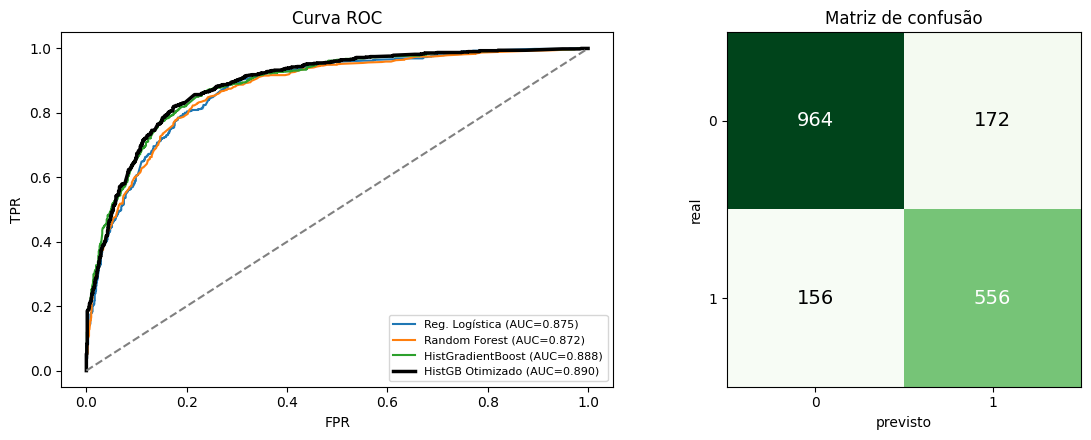

In [33]:
# Curva ROC + matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for nome in ["Reg. Logística","Random Forest","HistGradientBoost"]:
    pr = pipes_treinados[nome].predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test, pr)
    axes[0].plot(fpr,tpr,label=f"{nome} (AUC={roc_auc_score(y_test,pr):.3f})")
fpr,tpr,_ = roc_curve(y_test, proba)
axes[0].plot(fpr,tpr,lw=2.5,color="black",label=f"HistGB Otimizado (AUC={roc_auc_score(y_test,proba):.3f})")
axes[0].plot([0,1],[0,1],"--",color="gray"); axes[0].set_title("Curva ROC")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(fontsize=8)
cm = confusion_matrix(y_test, pred)
im = axes[1].imshow(cm, cmap="Greens")
for i in range(2):
    for j in range(2):
        axes[1].text(j,i,cm[i,j],ha="center",va="center",fontsize=14,
                     color="white" if cm[i,j]>cm.max()/2 else "black")
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xlabel("previsto"); axes[1].set_ylabel("real"); axes[1].set_title("Matriz de confusão")
plt.tight_layout(); plt.show()

### 10.0.1 Confiabilidade do score como probabilidade



O lead score é usado de duas formas: para ordenar a fila de atendimento e para estimar a chance de um lead converter. O primeiro uso depende só da ordenação, o segundo exige que o número seja uma probabilidade real. Para verificar isso, os leads são agrupados em dez faixas pelo score, comparando, em cada faixa, o score médio previsto com a conversão observada. Se o score for uma probabilidade confiável, as duas colunas serão próximas.

In [34]:
# Verifica se o score pode ser lido como probabilidade:
# agrupa os leads por faixa de score e compara o previsto com a conversão real observada.
faixas = pd.qcut(proba, q=10, duplicates="drop")
comparacao = pd.DataFrame({"score_previsto": proba, "converteu": y_test.values})
tabela = comparacao.groupby(faixas, observed=True).agg(
    score_medio_previsto=("score_previsto", "mean"),
    conversao_real=("converteu", "mean"),
    n_leads=("converteu", "size"),
)
tabela["diferenca"] = (tabela["score_medio_previsto"] - tabela["conversao_real"]).round(3)
print("Score previsto vs. conversão real por faixa:")
print(tabela.round(3).to_string())

Score previsto vs. conversão real por faixa:
                                  score_medio_previsto  conversao_real  n_leads  diferenca
(-2.9999999999999645e-06, 0.016]                 0.010           0.022      185     -0.012
(0.016, 0.046]                                   0.029           0.032      185     -0.003
(0.046, 0.0924]                                  0.066           0.076      185     -0.010
(0.0924, 0.143]                                  0.116           0.125      184     -0.009
(0.143, 0.272]                                   0.201           0.200      185      0.001
(0.272, 0.486]                                   0.358           0.362      185     -0.005
(0.486, 0.671]                                   0.582           0.592      184     -0.011
(0.671, 0.797]                                   0.724           0.714      185      0.010
(0.797, 0.932]                                   0.856           0.805      185      0.050
(0.932, 0.997]                               

## 10.1 Vazamento dos dados


Ao treinar o mesmo modelo final adicionando as colunas vazadas, podemos entender o impacto que teriam para inflar o resultado.

In [35]:
cat_vaz = cat_cols + ["Tags", "Lead Quality"]
pre_vaz = ColumnTransformer([("num", numeric_pipe, num_cols), ("cat", categorical_pipe, cat_vaz)])
Xv = df[num_cols + cat_vaz].copy()
Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(Xv, y, test_size=0.2, random_state=SEED, stratify=y)
pipe_vaz = Pipeline([("preprocess", pre_vaz),
                     ("model", HistGradientBoostingClassifier(random_state=SEED))]).fit(Xv_tr, yv_tr)
auc_vaz = roc_auc_score(yv_te, pipe_vaz.predict_proba(Xv_te)[:,1])
print("AUC modelo com as infos dísponiveis em produção (sem vazamento):   %.4f" % roc_auc_score(y_test, proba))
print("AUC modelo COM vazamento (Tags etc.): %.4f  <-- ilusorio" % auc_vaz)
print("\nO ganho de %.2f pontos de AUC desapareceria em producao:" % (auc_vaz - roc_auc_score(y_test, proba)))
print("essas colunas nao existem quando o lead acabou de chegar.")

AUC modelo com as infos dísponiveis em produção (sem vazamento):   0.8903
AUC modelo COM vazamento (Tags etc.): 0.9758  <-- ilusorio

O ganho de 0.09 pontos de AUC desapareceria em producao:
essas colunas nao existem quando o lead acabou de chegar.


O modelo com vazamento parece bem melhor (AUC 0,976), mas esse desempenho é irreal. O modelo honesto (0,890) é o número real, porque 'Tags' e 'Lead Quality' não existem quando o lead acabou de chegar (momento em que o Lead Scoring é útil).

## 10.2 Importância das features (interpretabilidade)

---



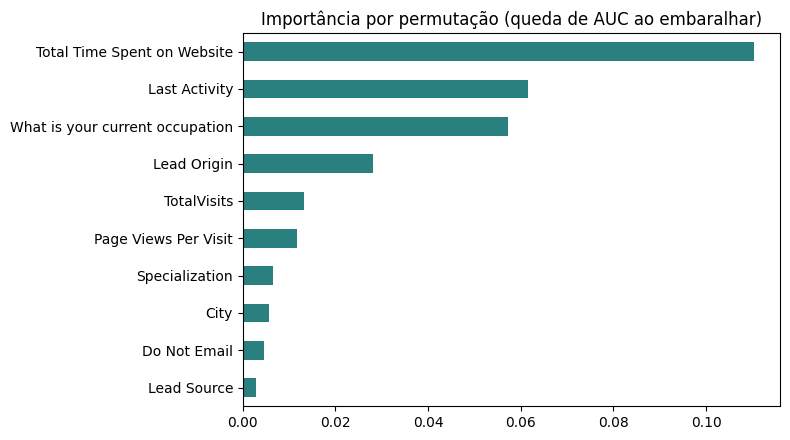

Total Time Spent on Website        0.1105
Last Activity                      0.0616
What is your current occupation    0.0572
Lead Origin                        0.0281
TotalVisits                        0.0132
Page Views Per Visit               0.0116
Specialization                     0.0064
City                               0.0056
Do Not Email                       0.0046
Lead Source                        0.0029


In [36]:
imp = permutation_importance(final, X_test, y_test, scoring="roc_auc",
                            n_repeats=5, random_state=SEED, n_jobs=-1)
imp_s = pd.Series(imp.importances_mean, index=features).sort_values(ascending=False).head(10)
imp_s.iloc[::-1].plot(kind="barh", color="#2a7f7f")
plt.title("Importância por permutação (queda de AUC ao embaralhar)"); plt.tight_layout(); plt.show()
print(imp_s.round(4).to_string())

Confirma a análise exploratória. 'Total Time Spent on Website' domina, seguido por origem e fonte do lead e ocupação. O modelo aprendeu sinais coerentes com o negócio e disponíveis na entrada do lead, sem vazamentos.

## 10.3 Como o modelo funcionaria no mundo real


Lead scoring serve para ordenar a fila de atendimentos e compreender o real potêncial de um lead comprar antes de iniciar o atendimento.

A pergunta que o modelo precisa responder é a eficacia de atender os primeiros da fila de maior score. Se a taxa de conversão for alta demonstra que o modelo consegue prever de forma prática quais os melhores leads, e balizar os resultados das campanhas de marketing.




In [37]:
ordem = np.argsort(-proba)
y_ord = y_test.values[ordem]
total_conv = y_test.sum()
print("Faixa de topo | precisão (conversão na faixa) | recall (convertidos capturados)")
for k in [0.10, 0.20, 0.30]:
    n = int(len(y_ord)*k)
    prec = y_ord[:n].mean(); rec = y_ord[:n].sum()/total_conv
    print(f"  top {int(k*100):>2d}% : precisão={prec:.1%} | recall={rec:.1%} ({int(y_ord[:n].sum())}/{int(total_conv)})")

Faixa de topo | precisão (conversão na faixa) | recall (convertidos capturados)
  top 10% : precisão=92.9% | recall=24.0% (171/712)
  top 20% : precisão=86.4% | recall=44.8% (319/712)
  top 30% : precisão=81.6% | recall=63.5% (452/712)


 Atacando só os 30% leads de maior score, a conversão na faixa fica em ~82% (contra 38,5% da fila bruta) e captura-se ~63% de todos os convertidos. Isso responde diretamente ao objetivo do modelo. É assim que o score vira priorização operacional e um balizador da entrega dos leads das campanhas.

## 10.4 Análise de erros e limitações


**Que tipos de erro o modelo comete mais?** Os erros se concentram nos falsos negativos do meio da distribuição. O modelo acerta bem os extremos (leads claramente quentes ou frios) e hesita no meio, onde qualquer classificador teria dificuldade, porque os próprios dados não separam bem esses casos.

**Há overfitting ou underfitting?** Nenhum dos dois. O AUC de validação cruzada no treino fica próximo do AUC de teste em todos os modelos, o que descarta overfitting. E o desempenho muito acima do baseline descarta underfitting.

**A métrica captura o objetivo?** Sim. A AUC mede a qualidade da ordenação, que é o que o lead scoring entrega, e a precisão por faixa de topo traduz isso no que o comercial sente.

**Há viés ou risco de generalização?** Sim. A base é de uma única empresa e um único período, então os padrões aprendidos podem não valer para outra operação ou outro momento, e mudanças de consumo e sazonalidade não são previstas pelo modelo.

A verificação por faixa mostrou que o número corresponde bem à conversão real na maior parte da distribuição, com leve superestimação nos leads de score mais alto (previsão cerca de 0,05 acima do observado). O score serve como probabilidade de conversão com boa aproximação.

**Quando o modelo não deve ser usado?** Para decidir desistir de um lead. O modelo prioriza, não elimina. Um lead de score baixo tem menos chance, mas ainda pode converter, e tratá-lo como causa perdida afetaria o resultado comercial e o próprio modelo, se os leads marcados como frios nunca forem atendidos, nunca se saberá quais deles teriam convertido, e esses falsos negativos deixam de ser corrigidos nas próximas versões. O score serve para ordenar a fila e estimar a probabilidade de conversão, não para eliminar contatos.

# 11. Comparação final dos modelos

In [38]:
ordem_cols = ["AUC_CV_treino","AUC","PR_AUC","F1","Precision","Recall","Accuracy","tempo_s"]
final_tab = pd.DataFrame(resultados).T.reindex(columns=ordem_cols)
final_tab = final_tab.sort_values("AUC", ascending=False)
final_tab.round(3)

,AUC_CV_treino,AUC,PR_AUC,F1,Precision,Recall,Accuracy,tempo_s
HistGB otimizado,0.907,0.890,0.834,0.772,0.764,0.781,0.822,NaN
Gradient Boosting,0.906,0.889,0.831,0.770,0.772,0.767,0.823,8.2
HistGradientBoost,0.906,0.888,0.837,0.769,0.766,0.772,0.821,4.7
Reg. Logística,0.898,0.875,0.806,0.755,0.723,0.791,0.802,3.7
Random Forest,0.896,0.872,0.806,0.743,0.751,0.736,0.804,19.3
Baseline (Dummy),0.500,0.500,0.385,0.000,0.000,0.000,0.615,6.9


A tabela reúne todos os modelos sob a mesma divisão de dados, o mesmo pré-processamento e a mesma validação cruzada, o que torna a comparação justa.

A escolha foi do HistGradientBoosting otimizado como modelo final. Ele tem o melhor AUC (0,890) e o melhor PR-AUC, à frente do Gradient Boosting, que fica praticamente empatado, e da regressão logística e do random forest, um pouco atrás. O baseline, com AUC 0,50, serve de referência e mostra que todos os modelos reais aprenderam de fato.

Dois pontos sustentam a escolha além do número. O AUC de validação cruzada fica próximo do AUC de teste em todos os modelos, sinal de que o desempenho é estável e não fruto de overfitting.

O HistGradientBoosting é escolhido por combinar o melhor desempenho de ordenação, treino rápido e ausência de overfitting, entregando tanto a fila de priorização quanto a probabilidade de conversão.

# 12. Boas práticas e rastreabilidade

**Seed:** 42, fixada em todo o notebook.

**Principais decisões de pré-processamento:** "Select" tratado como nulo; imputação por mediana nas numéricas e por categoria "Desconhecido" nas categóricas; padronização das numéricas; One-Hot com agrupamento de categorias raras; tudo dentro de pipeline, ajustado só no treino.

**Modelos testados:** baseline Dummy, regressão logística, random forest, Gradient Boosting e HistGradientBoosting.

**Hiperparâmetros relevantes:** no HistGB, learning_rate, max_leaf_nodes, max_depth, min_samples_leaf e l2_regularization. Melhor configuração: learning_rate 0,1, max_depth 5, max_leaf_nodes 56, min_samples_leaf 34, l2 0,0.

**Tempo aproximado de treino:** execução total em torno de dois minutos; a busca de hiperparâmetros é a etapa mais custosa, em menos de um minuto.

**Recursos computacionais:** Google Colab, CPU, sem GPU. Bibliotecas: pandas, numpy, scikit-learn, matplotlib.

**Limitações conhecidas:** base de uma única empresa e período (generalização limitada), sem dimensão temporal (não capta sazonalidade nem drift), leve superestimação do score nos leads de score mais alto.

**O que foi tentado e descartado:** usar todas as colunas (AUC ilusório de 0,976 por vazamento), calibração das probabilidades (o modelo já estava calibrado, sem ganho), feature engineering (dispensada para não arriscar vazamento).

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Métrica principal AUC | Base desbalanceada; o objetivo é ordenar, não classificar num corte fixo | Avaliação fiel ao uso do scoring |
| Tratar "Select" como nulo | É valor padrão de formulário, não uma categoria | Contagem de nulos correta |
| Descartar Tags e Lead Quality | Vazamento: anotação pós-contato, ausente no scoring | Evita o AUC artificial de 0,976 |
| Descartar variância nula e mais de 70% de nulos | Sem sinal aproveitável | Menos ruído e dimensionalidade |
| Imputar numéricas pela mediana | Robusta aos outliers de visitas | Imputação não distorcida |
| Nulos categóricos como "Desconhecido" | Não preencher é informativo | Preserva sinal |
| Pré-processamento em pipeline | Ajuste só no treino de cada fold | Sem vazamento de pré-processamento |
| Testar boosting além do template | EDA mostrou não linearidade e predomínio de categóricas | HistGB lidera a comparação |
| Otimizar só o HistGB | Refinar o líder, não um candidato pior | Ganho marginal, confirma teto nas features |
| Não aplicar calibração | Verificação por faixa mostrou o modelo já calibrado | Score usável como probabilidade sem camada extra |

# 13. Conclusão



O objetivo era construir um modelo lead scoring. Pontuar cada lead pela chance de conversão, permitindo ao time comercial priorizar a fila. A restrição que guiou o trabalho foi usar apenas informação disponível no momento em que o lead chega, sem o que o vendedor anota depois.

A melhor solução foi o HistGradientBoosting otimizado, com AUC de 0,89 no conjunto de teste, contra 0,50 do baseline. O salto sobre o baseline confirma que o modelo aprendeu padrão real, não facilidade da base. Na prática, atacando os 30% de maior score, a conversão sobe de 38,5% na fila bruta para 81,6%, o que responde diretamente ao objetivo comercial.

**Principais aprendizados.** Este MVP consolidou o fluxo completo de um projeto de machine learning do zero, três pontos que acredito que valem se destados:

O primeiro foi entender como cada família de modelo funciona e quando cada uma se aplica. A regressão logística, linear e interpretável, serve quando importa saber o peso de cada variável. O random forest e o boosting capturam relações não lineares e interações, e o boosting se mostrou o mais eficaz aqui porque a base é tabular, mistura numéricas e categóricas e tem relações que não são proporcionais. Pude entender melhor como cada modelo funciona para definir a melhor escolha.

O segundo foi aprender a preparar a base de forma crítica. Não bastava aplicar transformações: foi preciso entender o que cada valor significava. O caso do "Select" ensinou isso, um valor que parecia categoria e era ausência de resposta disfarçada. Tratar a base virou um exercício de compreender de onde os dados vêm, não só de limpá-los.

O terceiro, foi compreender o problema como um todo antes de modelar. Percebi que algumas colunas altamente preditivas, como Tags e Lead Quality, só são preenchidas depois que o vendedor já trabalhou o lead. Ou seja, são informações posterior ao momento da conversão, e não estariam disponíveis quando o modelo precisa pontuar um lead novo. Usá-las produziria um desempenho alto e falso. Aprendi que entender o momento em que cada dado surge, e o contexto de negócio por trás dele é deciso na hora de analisar os dados.


As limitações são conhecidas: a base é de uma única empresa e período, o que limita a generalização, e não há dimensão temporal para captar sazonalidade.

O modelo entrega dois usos com o mesmo score: a ordenação, para priorizar a fila, e a probabilidade de conversão, verificada por faixa e confiável com boa aproximação.

O próximo passo, seria incorporar o valor das vendas. Hoje o modelo estima a probabilidade de converter, somando o ticket de cada lead, seria possível estimar o valor esperado (probabilidade vezes valor) e responder não só quem converte, mas quem converte trazendo mais receita. Um lead de conversão média mas ticket alto pode valer mais que um lead quente de ticket baixo. É o caminho natural para ligar o scoring diretamente à receita, que é o objetivo final de Marketing e Vendas.